# DishFlow Optimization Network — Snooze-Style Brunch Edition v3  
## Golden Neurodivergent-First Teaching Notebook

**Learner role:** Head Dishwasher during an overloaded brunch rush.

**System goal:** Reduce clean-dish bottlenecks so cooked food can be plated and run before quality drops.

**This version is stronger than the prior notebook because it includes:**

1. a Snooze-style A.M. brunch restaurant profile,
2. realistic brunch residue dynamics,
3. plate-priority dish-flow logic,
4. two neural networks,
5. a Dish Scrape Olympics reward layer,
6. explicit code comments throughout,
7. output explanation after every major cell,
8. CRISP-DM framing from the Head Dishwasher’s point of view,
9. a final real-data implementation section explaining what would be required to make this real.

---

## Truth Boundary

This notebook uses **synthetic data**.  
The model is real.  
The training data is simulated.  
The restaurant logic is designed to resemble a high-volume brunch service, but it is not proprietary Snooze operational data.

# CRISP-DM Roadmap

We will follow the CRISP-DM data science workflow.

```text
1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation
6. Deployment Thinking
7. What Real Data Would Require
```

The Head Dishwasher’s causal chain:

```text
poor scrape quality
→ extra spray time
→ dish-pit backlog
→ no clean plates
→ cooked food waits
→ food risks going cold
→ runners wait
→ patrons wait longer
```

The ML system should learn how to protect the flow, not merely classify dirty dishes.

# 1. Business Understanding

## Restaurant profile represented by this synthetic data

This dataset represents a **high-volume brunch restaurant** with these operational assumptions:

```text
Service type: breakfast / brunch / lunch
Peak pressure: high
Dish demand: plate-heavy
Main bottleneck: clean plates during rush
Residue profile: eggs, syrup, starch, sauce, grease, mixed brunch residue
Labor condition: two dish workers doing work closer to a 4–6 person load
Operational risk: cooked food waits for plates and loses quality
```

## Core business question

```text
How can scraping, spraying, stacking, racking, and running dishes be optimized to reduce downstream food wait?
```

## Two-model design

| Model | Learns | Output |
|---|---|---|
| Scrape Delay Network | How much delay a dirty plate creates | scrape score + expected extra seconds |
| Dish Flow Action Network | What to do next under pressure | run, rescrape, spray/rack, batch, defer |

## Human training layer

The Dish Scrape Olympics becomes a reward system:

```text
visible score
public praise
sports-style narration
team competition
measurable improvement
```

This matters because the human behavior change is part of the system.

# Correct Path for Running This Notebook

Run each code cell in order.

Do not skip cells.

When a cell prints an output, read the explanation immediately below it before moving on.

If a cell fails, stop at that cell. The notebook is not judging you. The system needs repair.

In [1]:
# Cell 1 — Install and import required libraries.
# This cell prepares the Colab environment before any modeling begins.

# Install the core scientific Python libraries quietly.
# The -q flag means "quiet" so the output is not overwhelming.
!pip install -q numpy pandas scikit-learn matplotlib

# Import json so we can save structured model results at the end.
import json

# Import random so we can sample dish types and residue types.
import random

# Import Path so file paths are safer and easier to read.
from pathlib import Path

# Import numpy for numerical arrays and synthetic data generation.
import numpy as np

# Import pandas for readable tables.
import pandas as pd

# Import matplotlib for simple visual checks.
import matplotlib.pyplot as plt

# Import train_test_split so we can separate learning data from test data.
from sklearn.model_selection import train_test_split

# Import StandardScaler so numeric features are scaled before neural-network training.
from sklearn.preprocessing import StandardScaler

# Import Pipeline so scaling and modeling stay connected.
from sklearn.pipeline import Pipeline

# Import MLPRegressor for the neural network that predicts numeric outcomes.
from sklearn.neural_network import MLPRegressor

# Import MLPClassifier for the neural network that predicts action classes.
from sklearn.neural_network import MLPClassifier

# Import evaluation metrics for numeric predictions.
from sklearn.metrics import mean_absolute_error, r2_score

# Import evaluation metrics for classification predictions.
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Set a random seed so the same notebook run creates repeatable results.
RANDOM_SEED = 42

# Apply the seed to numpy.
np.random.seed(RANDOM_SEED)

# Apply the seed to Python's random module.
random.seed(RANDOM_SEED)

# Create an output folder for saved results.
OUTPUT_DIR = Path("dishflow_snooze_outputs")

# Create the folder if it does not already exist.
OUTPUT_DIR.mkdir(exist_ok=True)

# Print a short success message so the learner knows setup finished.
print("Setup complete. Libraries imported. Output folder is ready.")

Setup complete. Libraries imported. Output folder is ready.


## Output Explanation — Cell 1

You should see:

```text
Setup complete. Libraries imported. Output folder is ready.
```

That means the notebook environment is ready.

No model has been trained yet.

# 2. Data Understanding

## What the Head Dishwasher sees

A plate is not just dirty or clean.  
The dish pit sees several operational signals at once:

```text
dish type
residue type
residue coverage
stuck-food severity
scrape completeness
hot food waiting
clean plate inventory
dish-pit backlog
rack availability
worker fatigue
rush intensity
```

## Why brunch is different

Breakfast/brunch residue has its own physics:

```text
egg yolk = sticky and time-sensitive
syrup = sticky film
pancake / hash starch = smear and adhesion
hollandaise / sauce = oily film
mixed plates = high rework risk
```

Bad scraping during brunch is expensive because hot eggs, pancakes, and benedicts do not hold quality forever.

In [2]:
# Cell 2 — Define the restaurant vocabulary.
# This cell gives the synthetic model a controlled operating language.

# Define dish types common in a brunch restaurant.
# The numbers are IDs used by the machine learning model.
DISH_TYPES = {
    "large_entree_plate": 0,
    "pancake_plate": 1,
    "bowl": 2,
    "ramekin": 3,
    "coffee_cup": 4,
    "silverware_batch": 5,
}

# Define residue types that match brunch service.
# These are not equal difficulty; egg, syrup, starch, and mixed residue are harder.
RESIDUE_TYPES = {
    "egg_yolk": 0,
    "syrup": 1,
    "starch_hash_pancake": 2,
    "hollandaise_or_sauce": 3,
    "grease": 4,
    "mixed_brunch_residue": 5,
    "light_crumbs": 6,
}

# Define actions the dish-flow controller can recommend.
# These are operational decisions, not abstract labels.
ACTIONS = {
    0: "run_clean_plates_to_plating_line_now",
    1: "scrape_again_before_spray",
    2: "targeted_spray_then_vertical_rack",
    3: "batch_stack_same_shape_before_rack",
    4: "defer_low_priority_cups",
    5: "protect_dishwasher_from_rewash_overload",
}

# Print the vocabulary so the learner can inspect the system language.
print("Dish types:", DISH_TYPES)
print("Residue types:", RESIDUE_TYPES)
print("Action labels:", ACTIONS)

Dish types: {'large_entree_plate': 0, 'pancake_plate': 1, 'bowl': 2, 'ramekin': 3, 'coffee_cup': 4, 'silverware_batch': 5}
Residue types: {'egg_yolk': 0, 'syrup': 1, 'starch_hash_pancake': 2, 'hollandaise_or_sauce': 3, 'grease': 4, 'mixed_brunch_residue': 5, 'light_crumbs': 6}
Action labels: {0: 'run_clean_plates_to_plating_line_now', 1: 'scrape_again_before_spray', 2: 'targeted_spray_then_vertical_rack', 3: 'batch_stack_same_shape_before_rack', 4: 'defer_low_priority_cups', 5: 'protect_dishwasher_from_rewash_overload'}


## Output Explanation — Cell 2

This output shows the vocabulary the model will use.

The most important concept:

```text
The action labels are dish-flow decisions.
```

The model is not just saying “dirty” or “clean.”  
It is learning what the dish pit should do next.

In [3]:
# Cell 3 — Define helper functions and brunch-specific difficulty tables.
# This cell encodes domain knowledge before generating synthetic data.

# Convert a category ID into a one-hot vector.
# Example: if there are 3 dish types and the chosen type is 1, output is [0, 1, 0].
def one_hot(index, size):
    # Start with all zeros.
    values = [0.0] * size

    # Put a 1.0 in the selected category position.
    values[index] = 1.0

    # Return the one-hot vector.
    return values


# Residue difficulty controls how hard a residue is to remove.
# Higher values mean more downstream spray/scrape cost.
RESIDUE_DIFFICULTY = {
    "egg_yolk": 0.92,
    "syrup": 0.86,
    "starch_hash_pancake": 0.82,
    "hollandaise_or_sauce": 0.72,
    "grease": 0.55,
    "mixed_brunch_residue": 0.98,
    "light_crumbs": 0.20,
}

# Dish handling difficulty controls how awkward a dish is under speed pressure.
# Ramekins and silverware batches are deceptively time-consuming.
DISH_DIFFICULTY = {
    "large_entree_plate": 0.35,
    "pancake_plate": 0.32,
    "bowl": 0.52,
    "ramekin": 0.68,
    "coffee_cup": 0.42,
    "silverware_batch": 0.60,
}

# Dish demand weight reflects how often the item appears during brunch.
# Plates dominate because brunch plating depends heavily on them.
DISH_SAMPLING_POOL = (
    ["large_entree_plate"] * 34
    + ["pancake_plate"] * 24
    + ["bowl"] * 14
    + ["ramekin"] * 10
    + ["coffee_cup"] * 10
    + ["silverware_batch"] * 8
)

# Residue sampling weight reflects common brunch residue patterns.
# Mixed residue is intentionally frequent because brunch plates often combine egg, sauce, starch, and syrup.
RESIDUE_SAMPLING_POOL = (
    ["egg_yolk"] * 20
    + ["syrup"] * 16
    + ["starch_hash_pancake"] * 18
    + ["hollandaise_or_sauce"] * 14
    + ["grease"] * 8
    + ["mixed_brunch_residue"] * 18
    + ["light_crumbs"] * 6
)

# Print a compact confirmation.
print("Helper functions and brunch-specific difficulty tables are ready.")

Helper functions and brunch-specific difficulty tables are ready.


## Output Explanation — Cell 3

This cell defines the “physics” of the synthetic restaurant.

Important assumptions:

```text
egg, syrup, starch, and mixed residue are expensive
plates appear more often than cups
ramekins and silverware can be small but still costly
```

This is where the synthetic data becomes brunch-specific instead of generic.

# Synthetic Data Generator Design

Each synthetic observation represents one dish-flow moment.

The row includes:

```text
what item arrived
how dirty it is
how good the scrape was
how much pressure the kitchen is under
how much clean inventory exists
how likely this item is to create downstream delay
```

The targets are:

```text
scrape_quality_score
downstream_extra_seconds
best_dish_flow_action
dish_scrape_olympics_score
```

In [4]:
# Cell 4 — Generate Snooze-style synthetic dish-flow data.
# This is the heart of the notebook's simulated restaurant.

def generate_snooze_style_dishflow_data(n=12000):
    # Create a list that will hold human-readable rows.
    rows = []

    # Create a list that will hold numeric model features.
    X = []

    # Create a list for numeric targets: scrape quality and downstream extra seconds.
    y_regression = []

    # Create a list for action-class targets.
    y_action = []

    # Loop once for each synthetic dish-flow example.
    for _ in range(n):
        # Sample a dish type using brunch-weighted frequency.
        dish_name = random.choice(DISH_SAMPLING_POOL)

        # Sample a residue type using brunch-weighted frequency.
        residue_name = random.choice(RESIDUE_SAMPLING_POOL)

        # Convert dish name into numeric ID.
        dish_id = DISH_TYPES[dish_name]

        # Convert residue name into numeric ID.
        residue_id = RESIDUE_TYPES[residue_name]

        # Simulate whether this is a weekend shift.
        weekend_flag = np.random.choice([0, 1], p=[0.58, 0.42])

        # Simulate whether this row occurs during brunch rush.
        brunch_peak_flag = np.random.choice([0, 1], p=[0.45, 0.55])

        # Simulate whether the kitchen is currently plating hot food.
        if brunch_peak_flag:
            hot_window_flag = np.random.choice([0, 1], p=[0.25, 0.75])
        else:
            hot_window_flag = np.random.choice([0, 1], p=[0.65, 0.35])

        # More hot food waits during brunch peak.
        hot_food_waiting = np.random.randint(12, 52) if brunch_peak_flag else np.random.randint(0, 18)

        # Dish-pit backlog grows under brunch pressure.
        dishpit_backlog = np.random.randint(25, 110) if brunch_peak_flag else np.random.randint(0, 45)

        # Clean plate inventory is lower during pressure periods.
        clean_plate_inventory = np.random.randint(0, 45) if brunch_peak_flag else np.random.randint(25, 120)

        # Rack availability shrinks as backlog grows.
        rack_availability = int(np.clip(np.random.normal(6 - dishpit_backlog / 25, 2), 0, 10))

        # Worker fatigue increases with peak pressure and backlog.
        worker_fatigue = np.clip(np.random.normal(0.28 + 0.22 * brunch_peak_flag + dishpit_backlog / 240, 0.16), 0, 1)

        # Sprayer pressure varies but usually stays in a usable range.
        sprayer_pressure = np.clip(np.random.normal(0.68, 0.15), 0.2, 1.0)

        # Water temperature varies but usually stays warm/hot.
        water_temperature = np.clip(np.random.normal(0.74, 0.10), 0.35, 1.0)

        # Residue coverage is heavier under mixed brunch conditions.
        residue_coverage = np.clip(
            np.random.beta(2.4, 3.2) + 0.10 * (residue_name == "mixed_brunch_residue"),
            0,
            1,
        )

        # Stuck severity is higher for egg, syrup, starch, and mixed residue.
        stuck_base = RESIDUE_DIFFICULTY[residue_name] * 0.58

        # Add randomness to stuck severity.
        stuck_severity = np.clip(np.random.normal(stuck_base, 0.18), 0, 1)

        # Scrape completeness reflects server scrape quality before dish pit processing.
        # During rush, scraping often gets worse unless the reward system improves behavior.
        scrape_completeness = np.clip(
            np.random.normal(0.66 - 0.10 * brunch_peak_flag - 0.08 * worker_fatigue, 0.22),
            0,
            1,
        )

        # Simulate a reward/training effect from Dish Scrape Olympics.
        # This does not punish; it raises scrape completeness through visibility and competition.
        olympics_active = np.random.choice([0, 1], p=[0.45, 0.55])

        # If the Olympics is active, scraping improves modestly.
        if olympics_active:
            scrape_completeness = np.clip(scrape_completeness + np.random.normal(0.13, 0.05), 0, 1)

        # Time pressure combines hot food, backlog, low clean inventory, weekend pressure, and peak status.
        time_pressure = np.clip(
            (hot_food_waiting / 52)
            + (dishpit_backlog / 110)
            + (0.28 * weekend_flag)
            + (0.30 * brunch_peak_flag)
            + (0.35 * (clean_plate_inventory < 25)),
            0,
            2.6,
        )

        # Plate urgency is high when entree/pancake plates are needed and hot food is waiting.
        plate_urgency = int(
            dish_name in ["large_entree_plate", "pancake_plate"]
            and hot_food_waiting >= 18
            and clean_plate_inventory < 38
        )

        # Rewash risk rises with residue, stuck severity, low scrape completeness, and bad rack pressure.
        rewash_risk = np.clip(
            0.05
            + 0.38 * residue_coverage
            + 0.32 * stuck_severity
            - 0.42 * scrape_completeness
            + 0.15 * (rack_availability <= 2)
            + 0.10 * (sprayer_pressure < 0.45),
            0,
            1,
        )

        # Scrape quality score is a 0-100 human-facing score.
        scrape_quality = (
            100
            - 42 * residue_coverage
            - 30 * stuck_severity
            + 58 * scrape_completeness
            - 14 * RESIDUE_DIFFICULTY[residue_name]
            - 8 * worker_fatigue
            + 6 * olympics_active
            + np.random.normal(0, 4.5)
        )

        # Clip the scrape score into a real score range.
        scrape_quality = float(np.clip(scrape_quality, 0, 100))

        # Downstream extra seconds estimates how much extra dish-pit work this item creates.
        downstream_extra_seconds = (
            3
            + 24 * residue_coverage
            + 34 * stuck_severity
            + 18 * RESIDUE_DIFFICULTY[residue_name]
            + 10 * DISH_DIFFICULTY[dish_name]
            - 31 * scrape_completeness
            - 7 * sprayer_pressure
            - 4 * water_temperature
            + 0.13 * dishpit_backlog
            + 5.5 * worker_fatigue
            + 7.0 * rewash_risk
            + np.random.normal(0, 2.2)
        )

        # Clip the seconds so extreme values stay realistic for one item.
        downstream_extra_seconds = float(np.clip(downstream_extra_seconds, 0, 90))

        # Dish Scrape Olympics score rewards improvement and downstream help.
        olympics_score = (
            50
            + 0.34 * scrape_quality
            - 0.40 * downstream_extra_seconds
            + 12 * olympics_active
            + 8 * (rewash_risk < 0.15)
            + 6 * plate_urgency
        )

        # Clip Olympics score to a familiar 0-100 scale.
        olympics_score = float(np.clip(olympics_score, 0, 100))

        # Action policy: this creates the target the action network learns.
        # High-priority clean plate movement comes first when hot food needs plates.
        if plate_urgency and scrape_quality >= 55 and rewash_risk < 0.45:
            action = 0

        # Protect the system from rewash overload when residue risk is too high.
        elif rewash_risk >= 0.68 or (stuck_severity > 0.78 and scrape_completeness < 0.48):
            action = 5

        # Rescrape before spray when upstream scrape quality is poor.
        elif scrape_quality < 50:
            action = 1

        # Cups can often wait during plate starvation.
        elif dish_name == "coffee_cup" and hot_food_waiting > 10:
            action = 4

        # Batch similar items when rack availability is tight.
        elif rack_availability <= 2:
            action = 3

        # Default efficient flow.
        else:
            action = 2

        # Build the numeric feature vector.
        features = (
            one_hot(dish_id, len(DISH_TYPES))
            + one_hot(residue_id, len(RESIDUE_TYPES))
            + [
                residue_coverage,
                stuck_severity,
                scrape_completeness,
                dishpit_backlog / 110,
                clean_plate_inventory / 120,
                hot_food_waiting / 52,
                rack_availability / 10,
                sprayer_pressure,
                water_temperature,
                worker_fatigue,
                weekend_flag,
                brunch_peak_flag,
                hot_window_flag,
                olympics_active,
                time_pressure / 2.6,
                plate_urgency,
                rewash_risk,
            ]
        )

        # Create the readable row for inspection.
        row = {
            "dish_name": dish_name,
            "residue_name": residue_name,
            "weekend_flag": weekend_flag,
            "brunch_peak_flag": brunch_peak_flag,
            "hot_window_flag": hot_window_flag,
            "residue_coverage": residue_coverage,
            "stuck_severity": stuck_severity,
            "scrape_completeness": scrape_completeness,
            "dishpit_backlog": dishpit_backlog,
            "clean_plate_inventory": clean_plate_inventory,
            "hot_food_waiting": hot_food_waiting,
            "rack_availability": rack_availability,
            "sprayer_pressure": sprayer_pressure,
            "water_temperature": water_temperature,
            "worker_fatigue": worker_fatigue,
            "time_pressure": time_pressure,
            "plate_urgency": plate_urgency,
            "rewash_risk": rewash_risk,
            "olympics_active": olympics_active,
            "scrape_quality": scrape_quality,
            "downstream_extra_seconds": downstream_extra_seconds,
            "olympics_score": olympics_score,
            "action": action,
            "action_name": ACTIONS[action],
        }

        # Store the readable row.
        rows.append(row)

        # Store the numeric features.
        X.append(features)

        # Store the numeric regression targets.
        y_regression.append([scrape_quality, downstream_extra_seconds, olympics_score])

        # Store the action target.
        y_action.append(action)

    # Convert readable rows into a DataFrame.
    df = pd.DataFrame(rows)

    # Convert features into a numpy matrix.
    X = np.array(X, dtype=np.float32)

    # Convert regression targets into a numpy matrix.
    y_regression = np.array(y_regression, dtype=np.float32)

    # Convert action targets into a numpy vector.
    y_action = np.array(y_action, dtype=np.int64)

    # Return all generated objects.
    return df, X, y_regression, y_action


# Generate the synthetic dataset.
df, X, y_regression, y_action = generate_snooze_style_dishflow_data(n=12000)

# Print key shape information.
print("Synthetic rows:", len(df))
print("Feature matrix shape:", X.shape)
print("Regression target shape:", y_regression.shape)
print("Action target shape:", y_action.shape)

# Display the first five rows for human inspection.
df.head()

Synthetic rows: 12000
Feature matrix shape: (12000, 30)
Regression target shape: (12000, 3)
Action target shape: (12000,)


,dish_name,residue_name,weekend_flag,brunch_peak_flag,hot_window_flag,residue_coverage,stuck_severity,scrape_completeness,dishpit_backlog,clean_plate_inventory,...,worker_fatigue,time_pressure,plate_urgency,rewash_risk,olympics_active,scrape_quality,downstream_extra_seconds,olympics_score,action,action_name
0,ramekin,egg_yolk,0,1,1,0.406192,0.223115,0.464894,107,22,...,1.000000,2.238112,0,0.080494,1,84.989529,40.264816,82.790514,2,targeted_spray_then_vertical_rack
1,large_entree_plate,light_crumbs,1,0,0,0.699250,0.000000,0.880972,36,75,...,0.345980,0.645734,0,0.095707,0,100.000000,0.000000,92.000000,3,batch_stack_same_shape_before_rack
2,pancake_plate,syrup,1,0,0,0.297324,0.168215,0.900579,28,87,...,0.368461,0.592238,0,0.000000,1,100.000000,3.945413,100.000000,2,targeted_spray_then_vertical_rack
3,large_entree_plate,egg_yolk,0,0,0,0.505564,0.503323,0.901367,8,112,...,0.186032,0.188112,0,0.174604,0,100.000000,16.208772,77.516491,3,batch_stack_same_shape_before_rack
4,silverware_batch,egg_yolk,1,1,1,0.239063,0.549268,0.432809,89,34,...,0.767614,2.273706,0,0.134830,0,83.629230,44.618355,68.586596,2,targeted_spray_then_vertical_rack


## Output Explanation — Cell 4

You should see:

```text
Synthetic rows: 12000
Feature matrix shape: (12000, 30)
Regression target shape: (12000, 3)
Action target shape: (12000,)
```

Plain English:

```text
12000 simulated dish-flow moments were created.
Each moment has 30 input features.
The first neural network predicts 3 numeric values.
The second neural network predicts 1 action.
```

The table lets you inspect whether the data feels like brunch pressure rather than generic restaurant data.

In [5]:
# Cell 5 — Inspect the dataset at a high level.
# This cell gives a calm statistical overview before modeling.

# Select operational columns that matter most to the Head Dishwasher.
inspection_columns = [
    "residue_coverage",
    "stuck_severity",
    "scrape_completeness",
    "dishpit_backlog",
    "clean_plate_inventory",
    "hot_food_waiting",
    "rack_availability",
    "worker_fatigue",
    "time_pressure",
    "rewash_risk",
    "scrape_quality",
    "downstream_extra_seconds",
    "olympics_score",
]

# Show summary statistics for the selected columns.
df[inspection_columns].describe()

,residue_coverage,stuck_severity,scrape_completeness,dishpit_backlog,clean_plate_inventory,hot_food_waiting,rack_availability,worker_fatigue,time_pressure,rewash_risk,scrape_quality,downstream_extra_seconds,olympics_score
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,0.447987,0.464223,0.619702,46.838000,44.567167,21.010500,3.680000,0.588167,1.218942,0.174002,86.572375,31.935673,78.230273
std,0.197528,0.206200,0.225884,30.218808,32.430751,14.518286,2.225012,0.259086,0.734942,0.144596,14.565211,15.205862,15.634977
min,0.010766,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22.967152,0.000000,25.097784
25%,0.297987,0.329039,0.464612,25.000000,20.000000,10.000000,2.000000,0.384062,0.512273,0.044077,77.092377,21.251916,66.213852
50%,0.436162,0.472522,0.624470,40.000000,36.000000,17.000000,4.000000,0.593127,1.291923,0.157326,90.722313,31.849098,79.703177
75%,0.590573,0.607073,0.787937,71.000000,67.000000,33.000000,5.000000,0.801898,1.866381,0.271387,100.000000,42.525681,91.817310
max,1.000000,1.000000,1.000000,109.000000,119.000000,51.000000,10.000000,1.000000,2.600000,0.773637,100.000000,83.804470,100.000000


## Output Explanation — Cell 5

This table shows:

```text
count = number of examples
mean = average value
std = variation
min/max = range
25/50/75% = distribution checkpoints
```

Use this to answer:

```text
Is the synthetic restaurant overloaded?
Are some plates meaningfully worse than others?
Does dish-pit delay vary enough for a model to learn?
```

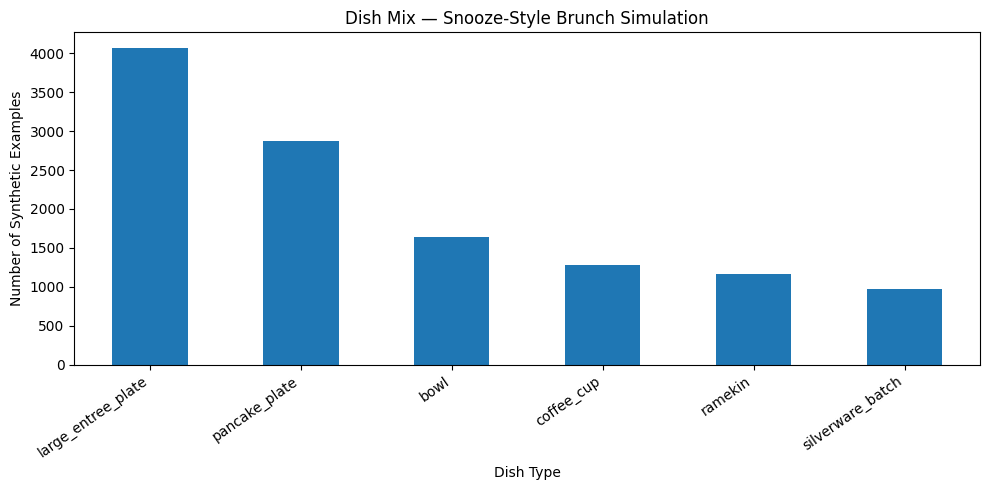

,count
dish_name,
large_entree_plate,4066
pancake_plate,2875
bowl,1640
coffee_cup,1282
ramekin,1167
silverware_batch,970


In [6]:
# Cell 6 — Visual check: dish type distribution.
# This verifies that the dataset is plate-heavy.

# Count how many times each dish type appears.
dish_counts = df["dish_name"].value_counts()

# Create a bar chart.
plt.figure(figsize=(10, 5))
dish_counts.plot(kind="bar")
plt.title("Dish Mix — Snooze-Style Brunch Simulation")
plt.xlabel("Dish Type")
plt.ylabel("Number of Synthetic Examples")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

# Print the counts below the chart.
dish_counts

## Output Explanation — Cell 6

The chart should show that entree and pancake plates dominate.

That matters because the bottleneck is not “all dishes equally.”  
The bottleneck is often:

```text
clean plates needed for hot food
```

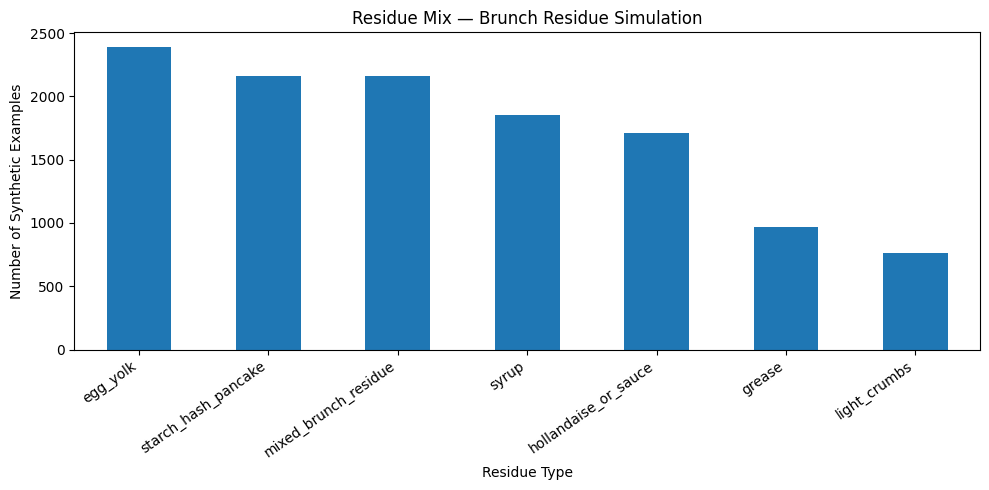

,count
residue_name,
egg_yolk,2387
starch_hash_pancake,2161
mixed_brunch_residue,2158
syrup,1853
hollandaise_or_sauce,1709
grease,966
light_crumbs,766


In [7]:
# Cell 7 — Visual check: residue distribution.
# This verifies that brunch residue is represented.

# Count how often each residue type appears.
residue_counts = df["residue_name"].value_counts()

# Create a bar chart.
plt.figure(figsize=(10, 5))
residue_counts.plot(kind="bar")
plt.title("Residue Mix — Brunch Residue Simulation")
plt.xlabel("Residue Type")
plt.ylabel("Number of Synthetic Examples")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

# Print the counts below the chart.
residue_counts

## Output Explanation — Cell 7

The chart should show frequent egg, syrup, starch, sauce, and mixed residue.

That is the correct direction for brunch.

The model needs these residue types because they change:

```text
scrape difficulty
spray time
rewash risk
dishwasher load
```

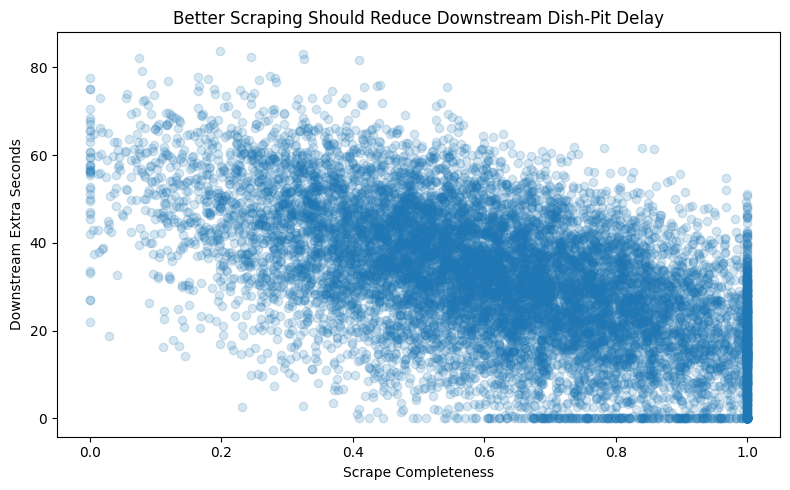

In [8]:
# Cell 8 — Visual check: scrape completeness versus downstream delay.
# This chart checks whether better scraping generally reduces extra dish-pit time.

# Create scatter plot.
plt.figure(figsize=(8, 5))
plt.scatter(df["scrape_completeness"], df["downstream_extra_seconds"], alpha=0.18)
plt.title("Better Scraping Should Reduce Downstream Dish-Pit Delay")
plt.xlabel("Scrape Completeness")
plt.ylabel("Downstream Extra Seconds")
plt.tight_layout()
plt.show()

## Output Explanation — Cell 8

The general pattern should slope downward:

```text
higher scrape completeness → fewer extra seconds
```

It will not be perfectly clean because other variables also matter:

```text
residue type
rack availability
sprayer pressure
backlog
worker fatigue
```

That messiness is realistic.

In [9]:
# Cell 9 — Visual check: Dish Scrape Olympics effect.
# This compares scrape completeness when the Olympics reward loop is active versus inactive.

# Group by whether the Olympics system is active.
olympics_effect = df.groupby("olympics_active")[
    ["scrape_completeness", "scrape_quality", "downstream_extra_seconds", "olympics_score"]
].mean()

# Show the comparison table.
olympics_effect

,scrape_completeness,scrape_quality,downstream_extra_seconds,olympics_score
olympics_active,,,,
0,0.551571,81.393729,34.207939,68.634624
1,0.676468,90.887121,30.042465,86.225182


## Output Explanation — Cell 9

This table compares two synthetic conditions:

```text
0 = Dish Scrape Olympics not active
1 = Dish Scrape Olympics active
```

In this simulated data, the Olympics condition should improve scrape quality and scoring.

This models your real-world insight:

```text
reward and public skill recognition can change mundane behavior
```

In [10]:
# Cell 10 — Split the data into train and test sets.
# This protects us from evaluating the model on the same examples it studied.

# Split features and labels.
X_train, X_test, y_reg_train, y_reg_test, y_action_train, y_action_test = train_test_split(
    X,
    y_regression,
    y_action,
    test_size=0.25,
    random_state=RANDOM_SEED,
    stratify=y_action,
)

# Print the split sizes.
print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

Training rows: 9000
Test rows: 3000


## Output Explanation — Cell 10

You should see:

```text
Training rows: 9000
Test rows: 3000
```

Plain English:

```text
The model studies 9000 examples.
The model is tested on 3000 examples it did not study.
```

This prevents a false sense of performance.

# 4. Modeling

We now train two neural networks.

## Network 1 — Scrape Delay Network

Predicts:

```text
scrape quality
extra downstream seconds
Dish Scrape Olympics score
```

## Network 2 — Dish Flow Action Network

Predicts the best operational action:

```text
run plates now
scrape again
spray/rack
batch stack
defer cups
protect from rewash overload
```

In [11]:
# Cell 11 — Train the Scrape Delay Network.
# This is a neural network for numeric prediction.

# Create a modeling pipeline.
scrape_delay_network = Pipeline(
    steps=[
        # Scale numeric features so the neural network trains more reliably.
        ("scaler", StandardScaler()),

        # Train a multi-layer perceptron regressor.
        # It predicts scrape quality, downstream seconds, and Olympics score.
        (
            "mlp",
            MLPRegressor(
                hidden_layer_sizes=(128, 96, 48),
                activation="relu",
                solver="adam",
                alpha=0.0005,
                learning_rate_init=0.001,
                max_iter=600,
                random_state=RANDOM_SEED,
                early_stopping=True,
            ),
        ),
    ]
)

# Fit the network using training data.
scrape_delay_network.fit(X_train, y_reg_train)

# Print confirmation.
print("Scrape Delay Network trained.")

Scrape Delay Network trained.


## Output Explanation — Cell 11

You should see:

```text
Scrape Delay Network trained.
```

That means the first neural network has learned from synthetic examples.

It now attempts to predict:

```text
scrape quality
extra dish-pit seconds
Olympics score
```

In [12]:
# Cell 12 — Train the Dish Flow Action Network.
# This is a neural network for operational action classification.

# Create a modeling pipeline.
dish_flow_action_network = Pipeline(
    steps=[
        # Scale features before neural-network classification.
        ("scaler", StandardScaler()),

        # Train a multi-layer perceptron classifier.
        (
            "mlp",
            MLPClassifier(
                hidden_layer_sizes=(128, 96, 48),
                activation="relu",
                solver="adam",
                alpha=0.0005,
                learning_rate_init=0.001,
                max_iter=600,
                random_state=RANDOM_SEED,
                early_stopping=True,
            ),
        ),
    ]
)

# Fit the classifier using training examples.
dish_flow_action_network.fit(X_train, y_action_train)

# Print confirmation.
print("Dish Flow Action Network trained.")

Dish Flow Action Network trained.


## Output Explanation — Cell 12

You should see:

```text
Dish Flow Action Network trained.
```

That means the second neural network has learned to select actions from the synthetic policy.

This is closer to dish-pit flow control than a basic dirty/clean classifier.

# 5. Evaluation

Evaluation answers:

```text
Did the model learn the synthetic restaurant logic?
How wrong are its timing predictions?
How often does it choose the correct dish-flow action?
Which action classes confuse it?
```

In [13]:
# Cell 13 — Evaluate the Scrape Delay Network.
# This cell measures numeric prediction quality.

# Predict scrape quality, downstream seconds, and Olympics score for test rows.
y_reg_pred = scrape_delay_network.predict(X_test)

# Calculate model error for scrape quality.
scrape_quality_mae = mean_absolute_error(y_reg_test[:, 0], y_reg_pred[:, 0])

# Calculate model error for extra downstream seconds.
extra_seconds_mae = mean_absolute_error(y_reg_test[:, 1], y_reg_pred[:, 1])

# Calculate model error for Olympics score.
olympics_score_mae = mean_absolute_error(y_reg_test[:, 2], y_reg_pred[:, 2])

# Calculate R² for scrape quality.
scrape_quality_r2 = r2_score(y_reg_test[:, 0], y_reg_pred[:, 0])

# Calculate R² for downstream seconds.
extra_seconds_r2 = r2_score(y_reg_test[:, 1], y_reg_pred[:, 1])

# Calculate R² for Olympics score.
olympics_score_r2 = r2_score(y_reg_test[:, 2], y_reg_pred[:, 2])

# Store metrics in a dictionary.
regression_metrics = {
    "scrape_quality_mae_points": float(scrape_quality_mae),
    "extra_seconds_mae": float(extra_seconds_mae),
    "olympics_score_mae_points": float(olympics_score_mae),
    "scrape_quality_r2": float(scrape_quality_r2),
    "extra_seconds_r2": float(extra_seconds_r2),
    "olympics_score_r2": float(olympics_score_r2),
}

# Show the metrics.
regression_metrics

{'scrape_quality_mae_points': 3.059528112411499,
 'extra_seconds_mae': 1.8966492414474487,
 'olympics_score_mae_points': 2.0495944023132324,
 'scrape_quality_r2': 0.9208993315696716,
 'extra_seconds_r2': 0.9753223657608032,
 'olympics_score_r2': 0.9723600745201111}

## Output Explanation — Cell 13

Important terms:

```text
MAE = average size of the model's error
R² = how much pattern the model learned
```

Good direction:

```text
lower MAE is better
higher R² is better
```

This does not prove real-world performance.  
It proves the synthetic learning pipeline works.

In [14]:
# Cell 14 — Evaluate the Dish Flow Action Network.
# This cell measures action prediction quality.

# Predict actions for the test examples.
y_action_pred = dish_flow_action_network.predict(X_test)

# Calculate action accuracy.
action_accuracy = accuracy_score(y_action_test, y_action_pred)

# Store action metric.
action_metrics = {
    "action_accuracy": float(action_accuracy)
}

# Show action metric.
action_metrics

{'action_accuracy': 0.9563333333333334}

## Output Explanation — Cell 14

Accuracy means:

```text
How often did the model choose the same action as the synthetic policy?
```

Because the data is synthetic, high accuracy means:

```text
The network learned the simulated operational rules.
```

It does not mean the model is ready to manage a real dish pit.

In [15]:
# Cell 15 — Print a detailed classification report.
# This helps identify which actions are easy or hard for the model.

# Create the action names in numeric order.
action_names = [ACTIONS[i] for i in sorted(ACTIONS)]

# Print precision, recall, and F1 for each action class.
print(
    classification_report(
        y_action_test,
        y_action_pred,
        target_names=action_names,
        zero_division=0,
    )
)

                                         precision    recall  f1-score   support

   run_clean_plates_to_plating_line_now       0.97      0.99      0.98       624
              scrape_again_before_spray       0.41      0.40      0.41        40
      targeted_spray_then_vertical_rack       0.98      0.98      0.98      1516
     batch_stack_same_shape_before_rack       0.96      0.95      0.95       554
                defer_low_priority_cups       0.91      0.96      0.93       223
protect_dishwasher_from_rewash_overload       0.55      0.26      0.35        43

                               accuracy                           0.96      3000
                              macro avg       0.80      0.76      0.77      3000
                           weighted avg       0.95      0.96      0.95      3000



## Output Explanation — Cell 15

The report includes:

```text
precision = when the model predicts this action, how often is it right?
recall = when this action is truly needed, how often does the model catch it?
f1-score = balance of precision and recall
support = how many test examples had this action
```

Pay special attention to rare but important classes, especially:

```text
protect_dishwasher_from_rewash_overload
run_clean_plates_to_plating_line_now
```

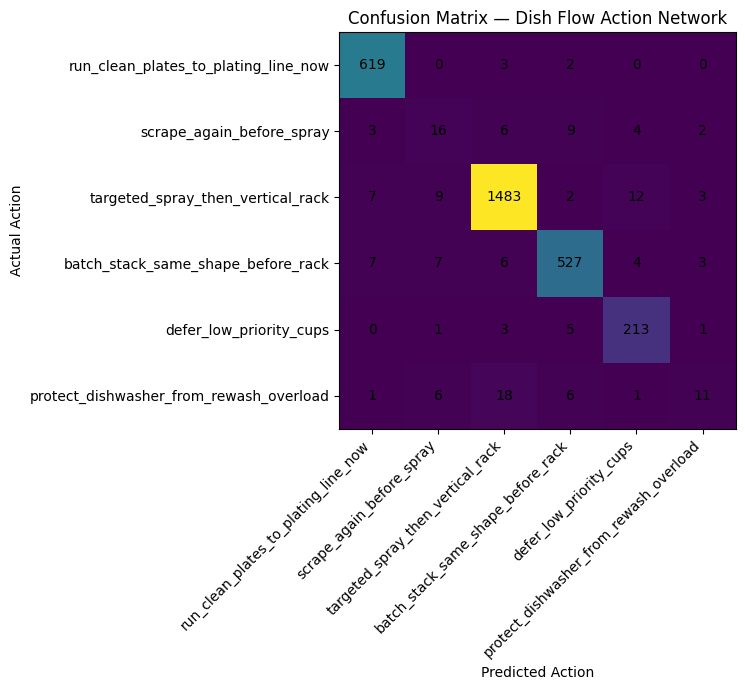

In [16]:
# Cell 16 — Create a confusion matrix.
# This shows where action predictions are confused.

# Calculate the confusion matrix.
cm = confusion_matrix(y_action_test, y_action_pred)

# Create the plot.
plt.figure(figsize=(9, 7))
plt.imshow(cm)
plt.title("Confusion Matrix — Dish Flow Action Network")
plt.xlabel("Predicted Action")
plt.ylabel("Actual Action")
plt.xticks(range(len(action_names)), action_names, rotation=45, ha="right")
plt.yticks(range(len(action_names)), action_names)

# Put numeric counts inside each cell.
for row_index in range(cm.shape[0]):
    for col_index in range(cm.shape[1]):
        plt.text(col_index, row_index, cm[row_index, col_index], ha="center", va="center")

plt.tight_layout()
plt.show()

## Output Explanation — Cell 16

The diagonal cells are correct predictions.

Off-diagonal cells are mistakes.

Plain English:

```text
A strong model has most counts on the diagonal.
```

For a real system, confusion between “spray/rack” and “protect from rewash overload” would be operationally serious.

# Human-Readable Recommendations

The next cell turns model outputs into dish-pit language.

This matters because a real worker does not need raw probabilities.

A real worker needs:

```text
What is this?
Why does it matter?
What should I do next?
```

In [17]:
# Cell 17 — Generate human-readable recommendations.
# This converts model outputs into operational guidance.

# Create an empty list for recommendation rows.
recommendations = []

# Use the first 12 test examples.
for i in range(12):
    # Get predicted scrape quality.
    predicted_scrape_quality = float(y_reg_pred[i, 0])

    # Get predicted extra dish-pit seconds.
    predicted_extra_seconds = float(y_reg_pred[i, 1])

    # Get predicted Olympics score.
    predicted_olympics_score = float(y_reg_pred[i, 2])

    # Get predicted action ID.
    predicted_action_id = int(y_action_pred[i])

    # Get actual synthetic action ID.
    actual_action_id = int(y_action_test[i])

    # Build a readable row.
    recommendations.append(
        {
            "sample": i + 1,
            "predicted_scrape_quality": round(predicted_scrape_quality, 2),
            "predicted_extra_seconds": round(predicted_extra_seconds, 2),
            "predicted_olympics_score": round(predicted_olympics_score, 2),
            "predicted_action": ACTIONS[predicted_action_id],
            "actual_synthetic_action": ACTIONS[actual_action_id],
            "action_match": predicted_action_id == actual_action_id,
        }
    )

# Display recommendations as a table.
pd.DataFrame(recommendations)

,sample,predicted_scrape_quality,predicted_extra_seconds,predicted_olympics_score,predicted_action,actual_synthetic_action,action_match
0,1,97.65,21.09,84.72,targeted_spray_then_vertical_rack,targeted_spray_then_vertical_rack,True
1,2,93.90,27.45,78.86,defer_low_priority_cups,defer_low_priority_cups,True
2,3,100.76,22.80,95.94,targeted_spray_then_vertical_rack,targeted_spray_then_vertical_rack,True
3,4,70.65,41.06,68.58,targeted_spray_then_vertical_rack,targeted_spray_then_vertical_rack,True
4,5,101.12,25.27,94.20,targeted_spray_then_vertical_rack,targeted_spray_then_vertical_rack,True
5,6,99.51,23.64,95.03,targeted_spray_then_vertical_rack,targeted_spray_then_vertical_rack,True
6,7,82.47,50.26,70.00,defer_low_priority_cups,defer_low_priority_cups,True
7,8,94.68,28.25,72.52,batch_stack_same_shape_before_rack,batch_stack_same_shape_before_rack,True
8,9,68.56,35.58,58.64,targeted_spray_then_vertical_rack,targeted_spray_then_vertical_rack,True
9,10,92.15,30.71,85.17,targeted_spray_then_vertical_rack,targeted_spray_then_vertical_rack,True


## Output Explanation — Cell 17

Each row is a simulated dish-flow recommendation.

The table answers:

```text
How good was the scrape?
How much delay might this item add?
What should the dish pit do?
Did the prediction match the synthetic target?
```

This is the bridge from model output to Head Dishwasher decision-making.

# Dish Scrape Olympics Scorecard

The scorecard should not shame workers.

It should make skill visible.

## Example scoring frame

```text
Clean Surface Score: How much residue was removed?
Rim Control Score: Did the server clear the high-delay rim zone?
Dish-Pit Assist Score: How many downstream seconds were saved?
Flow Hero Bonus: Did this help hot food get plated?
No Rewash Bonus: Did this avoid rework?
```

The hidden principle:

```text
Reward the behavior that protects the whole system.
```

In [18]:
# Cell 18 — Build a Dish Scrape Olympics leaderboard.
# This is a synthetic example of reward-based behavior feedback.

# Copy a subset of the data so we can create a fake server/team layer.
leaderboard_df = df.copy()

# Create synthetic server names.
# In real life, use anonymized IDs or team names unless workers consent to names.
server_pool = ["Team Sunrise", "Team Hollandaise", "Team Pancake", "Team Hashbrown", "Team Espresso"]

# Assign synthetic teams randomly.
leaderboard_df["server_team"] = np.random.choice(server_pool, size=len(leaderboard_df))

# Group by team and calculate performance averages.
leaderboard = (
    leaderboard_df
    .groupby("server_team")
    .agg(
        average_olympics_score=("olympics_score", "mean"),
        average_scrape_quality=("scrape_quality", "mean"),
        average_extra_seconds=("downstream_extra_seconds", "mean"),
        average_rewash_risk=("rewash_risk", "mean"),
        examples=("server_team", "count"),
    )
    .sort_values("average_olympics_score", ascending=False)
)

# Display the leaderboard.
leaderboard

,average_olympics_score,average_scrape_quality,average_extra_seconds,average_rewash_risk,examples
server_team,,,,,
Team Sunrise,78.780323,87.002072,31.631888,0.171367,2448
Team Espresso,78.403580,86.618800,31.691733,0.171530,2409
Team Pancake,78.248979,86.699765,32.027673,0.175395,2364
Team Hollandaise,78.115329,86.485705,31.795484,0.172163,2393
Team Hashbrown,77.587702,86.045346,32.543090,0.179666,2386


## Output Explanation — Cell 18

This leaderboard demonstrates the behavioral layer.

It rewards teams for:

```text
better scrape quality
lower downstream delay
lower rewash risk
better dish-pit support
```

In a real restaurant, the ethical design matters:

```text
team-based > individual shame
reward-based > punishment-based
improvement trend > fixed ranking
```

# 6. Deployment Thinking

A real implementation would likely have three layers.

## Layer 1 — Perception

```text
camera sees plate
model estimates residue zones
model estimates scrape completeness
```

## Layer 2 — Flow State

```text
dish-pit backlog
clean plate inventory
dishwasher cycle state
hot food waiting
rack availability
runner availability
```

## Layer 3 — Recommendation / Feedback

```text
server scrape score
dish-pit next action
team scorecard
flow warning
```

The system should augment the Head Dishwasher, not override them.

# 7. What It Would Take To Do This With Real Data

This is the most important truth section.

To make this real, synthetic rows must be replaced by observed restaurant data.

## Minimum viable real-data system

You would need:

```text
1. plate image or short video before dish-pit processing
2. human label for scrape quality
3. residue label
4. dish type label
5. spray time
6. rack/stack action
7. whether rewash occurred
8. clean plate inventory timestamps
9. ticket fired timestamp
10. food ready timestamp
11. food plated timestamp
12. food run timestamp
13. shift context: weekday/weekend, rush level, staffing level
```

## Real labels needed

A trained observer or Head Dishwasher would label:

```text
scrape quality: 0-100
residue zones: center, rim, back-side, stuck edge
residue type: egg, syrup, starch, sauce, grease, mixed
spray method: angle, duration, rotation count
stack method: nested, vertical rack, batch by shape, deferred
outcome: clean first pass, rewash, delay, breakage, clog
```

## Minimum useful dataset size

A practical starting point:

```text
1,000–2,000 labeled dish events = early prototype
5,000–10,000 labeled dish events = useful supervised model
20,000+ dish events across multiple shifts = stronger operational model
```

For video or image segmentation, more data may be needed unless transfer learning is used.

## Privacy and labor safeguards

Do not build this as worker surveillance.

Required safeguards:

```text
blur faces
avoid customer identification
avoid punitive ranking
use team-level scoring where possible
get consent where required
store only needed footage
delete raw video after labels are extracted
separate coaching metrics from discipline
```

## Experimental validation

To prove impact, compare shifts:

```text
baseline shifts without model
training shifts with Dish Scrape Olympics only
model-assisted shifts with recommendations
```

Measure:

```text
average plate turnaround time
rewash rate
clean plate stockout events
food-ready-to-plated delay
food-plated-to-run delay
customer wait time
food temperature/quality complaints
worker strain or fatigue
```

## What would prove the “cuts wait time in half” claim?

You would need evidence like:

```text
Before: average cooked-food wait for plates = 8 minutes
After: average cooked-food wait for plates = 4 minutes or less
```

And you would need to show this was not caused by something else, such as:

```text
more staffing
lower customer volume
menu changes
different manager
different dishwasher machine settings
```

## Real-data functional status

With real data, this could become:

```text
computer vision model + operations model + human reward feedback system
```

Without real data, it remains:

```text
a valid synthetic teaching and prototyping system
```

In [19]:
# Cell 19 — Save all notebook outputs.
# This creates a JSON file that records metrics and truth status.

# Combine model metrics.
all_metrics = {
    **regression_metrics,
    **action_metrics,
    "synthetic_rows": int(len(df)),
    "feature_count": int(X.shape[1]),
    "training_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
}

# Create a structured result object.
results = {
    "metrics": all_metrics,
    "sample_recommendations": recommendations,
    "action_labels": ACTIONS,
    "truth_status": {
        "exists": [
            "Snooze-style brunch synthetic data generator",
            "Scrape Delay neural network",
            "Dish Flow Action neural network",
            "Dish Scrape Olympics reward layer",
            "evaluation metrics",
            "human-readable recommendations",
            "real-data implementation requirements section",
        ],
        "non_existent": [
            "real Snooze operational data",
            "real dish-pit camera footage",
            "real POS ticket timestamps",
            "real dishwasher sensor data",
            "deployed production system",
        ],
        "unverified": [
            "real-world wait-time reduction",
            "generalization to real restaurant shifts",
            "causal impact on food temperature",
            "worker adoption in live service",
        ],
        "functional_status": "Runnable Colab teaching notebook using synthetic data."
    },
}

# Save the JSON file.
with open(OUTPUT_DIR / "dishflow_snooze_golden_v3_results.json", "w") as f:
    json.dump(results, f, indent=2)

# Print saved location and metrics.
print("Saved results to:", OUTPUT_DIR / "dishflow_snooze_golden_v3_results.json")
print(json.dumps(all_metrics, indent=2))

Saved results to: dishflow_snooze_outputs/dishflow_snooze_golden_v3_results.json
{
  "scrape_quality_mae_points": 3.059528112411499,
  "extra_seconds_mae": 1.8966492414474487,
  "olympics_score_mae_points": 2.0495944023132324,
  "scrape_quality_r2": 0.9208993315696716,
  "extra_seconds_r2": 0.9753223657608032,
  "olympics_score_r2": 0.9723600745201111,
  "action_accuracy": 0.9563333333333334,
  "synthetic_rows": 12000,
  "feature_count": 30,
  "training_rows": 9000,
  "test_rows": 3000
}


## Output Explanation — Cell 19

This cell saves the notebook results into a JSON file.

That file records:

```text
metrics
sample recommendations
action labels
truth status
```

This is useful because model work should leave an evidence trail.

# Final V&T Statement

**Exists:** This notebook contains a Snooze-style brunch synthetic data generator, CRISP-DM framing, Head Dishwasher perspective, richly commented code, output explanations, two neural-network models, Dish Scrape Olympics scoring, visual checks, metrics, recommendations, and a real-data requirements section.

**Non-existent:** This notebook does not contain real Snooze operational data, real restaurant video, real worker data, real POS ticket logs, real dishwasher telemetry, or a deployed production interface.

**Unverified:** The claim that this system cuts patron wait time in half is not proven here. It would require real shift-level comparison, controlled measurement, and causal validation.

**Functional status:** This is a runnable Google Colab teaching notebook using synthetic data. It is suitable for learning, prototyping, explaining the system, and planning real-data collection.